# 🤖 Global Primates Watch — Machine Learning para Classificação de Risco

Este notebook implementa um modelo de Machine Learning para prever o risco de ameaça:
- Preparação de features (características)
- Treinamento de Random Forest
- Avaliação de performance
- Análise de importância de features
- Predições em novos dados

## 📦 Importações e Configuração

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Importações concluídas!")

✓ Importações concluídas!


## 📥 Carregar e Preparar Dados

In [3]:
# Carregar dados
geojson_path = project_root / 'data' / 'processed' / 'primates_map.geojson'
csv_path = project_root / 'data' / 'processed' / 'primates_species_clean.csv'

gdf = gpd.read_file(str(geojson_path))
df = pd.read_csv(str(csv_path))

print(f"✓ Dados carregados: {len(df)} espécies")
print(f"\nColunas disponíveis: {df.columns.tolist()}")

✓ Dados carregados: 526 espécies

Colunas disponíveis: ['id_no', 'sci_name', 'presence', 'origin', 'seasonal', 'compiler', 'yrcompiled', 'citation', 'subspecies', 'subpop', 'source', 'island', 'tax_comm', 'dist_comm', 'generalisd', 'legend', 'kingdom', 'phylum', 'class', 'order_', 'family', 'genus', 'category', 'marine', 'terrestria', 'freshwater', 'SHAPE_Leng', 'SHAPE_Area', 'category_pt', 'risco', 'geometry_wkt']


## 🔨 Engenharia de Features (Feature Engineering)

In [4]:
# Preparar dataset para ML
ml_data = gdf.copy()
# O GeoJSON já possui as colunas category e risco!

# Feature 1: Área de distribuição
ml_data['area_km2'] = ml_data.geometry.area / 1e6

# Feature 2: Centroide latitude
ml_data['centroid_lat'] = ml_data.geometry.centroid.y

# Feature 3: Centroide longitude
ml_data['centroid_lon'] = ml_data.geometry.centroid.x

# Feature 4: Perímetro
ml_data['perimeter_km'] = ml_data.geometry.length / 1000

# Feature 5: Razão perímetro/área
ml_data['fragmentation_index'] = ml_data['perimeter_km'] / (ml_data['area_km2'] + 1)

# Feature 6: Continente
def classify_continent(lon):
    if -180 <= lon < -60:
        return 0
    elif -60 <= lon < 40:
        return 1
    elif 40 <= lon < 100:
        return 2
    elif 100 <= lon <= 180:
        return 3
    return 4

ml_data['continent_code'] = ml_data['centroid_lon'].apply(classify_continent)

print("✓ Features criadas com sucesso!")


✓ Features criadas com sucesso!


## 🎯 Preparar Variável Alvo (Target)

In [5]:
# Criar variável alvo binária: ameaçado vs. não ameaçado
# Ameaçado: CR, EN, VU (categorias de risco)
# Não ameaçado: NT, LC (categorias seguras)

ml_data['is_threatened'] = ml_data['category'].isin(['CR', 'EN', 'VU']).astype(int)

print("✓ Variável alvo criada!")
print(f"\nDistribuição da variável alvo:")
print(ml_data['is_threatened'].value_counts())
print(f"\nPercentual:")
print(ml_data['is_threatened'].value_counts(normalize=True) * 100)

print(f"\n💡 Balanceamento:")
threatened_pct = (ml_data['is_threatened'] == 1).sum() / len(ml_data) * 100
print(f"  - Espécies ameaçadas: {threatened_pct:.1f}%")
print(f"  - Espécies não ameaçadas: {100 - threatened_pct:.1f}%")

✓ Variável alvo criada!

Distribuição da variável alvo:
is_threatened
1    349
0    177
Name: count, dtype: int64

Percentual:
is_threatened
1    66.34981
0    33.65019
Name: proportion, dtype: float64

💡 Balanceamento:
  - Espécies ameaçadas: 66.3%
  - Espécies não ameaçadas: 33.7%


## 🔄 Preparar Dados para Treinamento

In [6]:
# Selecionar features e target
feature_cols = ['area_km2', 'centroid_lat', 'centroid_lon', 'perimeter_km', 'fragmentation_index', 'continent_code']
X = ml_data[feature_cols].copy()
y = ml_data['is_threatened'].copy()

# Remover linhas com valores faltantes
valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx]
y = y[valid_idx]

print(f"✓ Dados preparados para treinamento!")
print(f"\nTamanho do dataset:")
print(f"  - Amostras: {len(X)}")
print(f"  - Features: {len(feature_cols)}")

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDivisão treino/teste:")
print(f"  - Treino: {len(X_train)} amostras")
print(f"  - Teste: {len(X_test)} amostras")

✓ Dados preparados para treinamento!

Tamanho do dataset:
  - Amostras: 526
  - Features: 6

Divisão treino/teste:
  - Treino: 420 amostras
  - Teste: 106 amostras


## 🌳 Treinar Random Forest

In [7]:
# Treinar modelo Random Forest
print("Treinando modelo Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✓ Modelo treinado com sucesso!")

# Fazer predições
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

print(f"\n📊 Performance do Modelo:")
print(f"\nAcurácia no conjunto de treino: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Acurácia no conjunto de teste: {accuracy_score(y_test, y_pred_test):.4f}")

Treinando modelo Random Forest...
✓ Modelo treinado com sucesso!

📊 Performance do Modelo:

Acurácia no conjunto de treino: 0.9262
Acurácia no conjunto de teste: 0.8491


## 📈 Avaliação Detalhada do Modelo

In [8]:
print("\n" + "="*70)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("="*70)

print(f"\nConjunto de Teste:")
print(classification_report(y_test, y_pred_test, target_names=['Não Ameaçado', 'Ameaçado']))

# Matriz de confusão
print(f"\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(f"\nInterpretação:")
print(f"  - Verdadeiros Negativos (TN): {cm[0,0]}")
print(f"  - Falsos Positivos (FP): {cm[0,1]}")
print(f"  - Falsos Negativos (FN): {cm[1,0]}")
print(f"  - Verdadeiros Positivos (TP): {cm[1,1]}")

# Validação cruzada
cv_scores = cross_val_score(rf_model, X, y, cv=5)
print(f"\nValidação Cruzada (5-fold):")
print(f"  - Scores: {cv_scores}")
print(f"  - Média: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


RELATÓRIO DE CLASSIFICAÇÃO

Conjunto de Teste:
              precision    recall  f1-score   support

Não Ameaçado       0.81      0.72      0.76        36
    Ameaçado       0.86      0.91      0.89        70

    accuracy                           0.85       106
   macro avg       0.84      0.82      0.83       106
weighted avg       0.85      0.85      0.85       106


Matriz de Confusão:
[[26 10]
 [ 6 64]]

Interpretação:
  - Verdadeiros Negativos (TN): 26
  - Falsos Positivos (FP): 10
  - Falsos Negativos (FN): 6
  - Verdadeiros Positivos (TP): 64

Validação Cruzada (5-fold):
  - Scores: [0.70754717 0.81904762 0.86666667 0.78095238 0.78095238]
  - Média: 0.7910 (+/- 0.0523)


## 🔍 Importância das Features


🔍 Importância das Features:
            Feature  Importância
       centroid_lon     0.269336
           area_km2     0.187743
       centroid_lat     0.165118
       perimeter_km     0.138940
fragmentation_index     0.135737
     continent_code     0.103127

✓ Gráfico de importância salvo: c:\Users\eferro\Desktop\Global Primates Watch\outputs\feature_importance.png


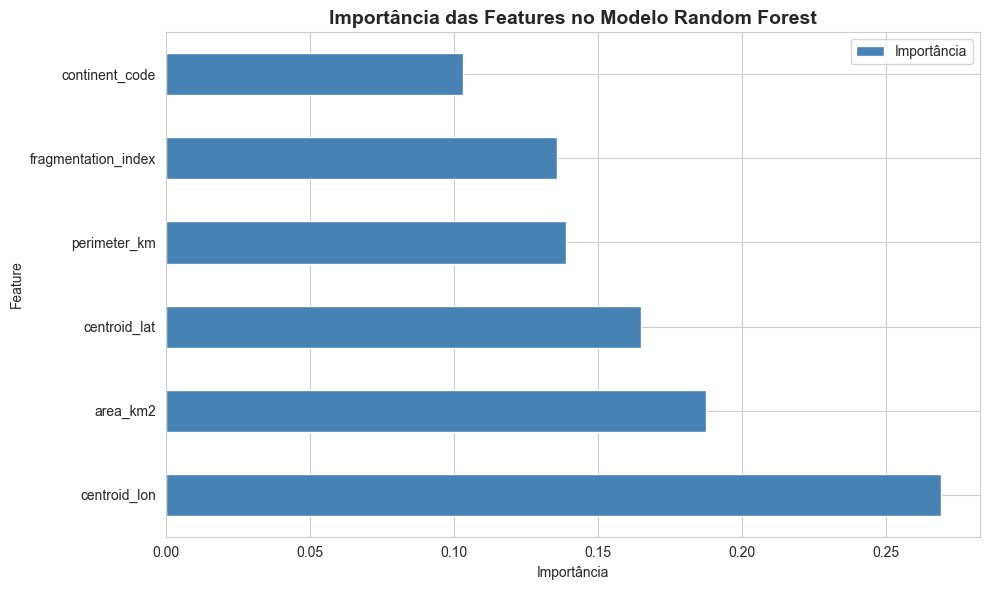

In [9]:
# Extrair importância das features
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importância': rf_model.feature_importances_
}).sort_values('Importância', ascending=False)

print("\n🔍 Importância das Features:")
print(feature_importance.to_string(index=False))

# Visualizar importância
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(x='Feature', y='Importância', kind='barh', ax=ax, color='steelblue')
ax.set_title('Importância das Features no Modelo Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')
ax.set_ylabel('Feature')
plt.tight_layout()

# Salvar figura
output_dir = project_root / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / 'feature_importance.png', dpi=300, bbox_inches='tight')

print(f"\n✓ Gráfico de importância salvo: {output_dir / 'feature_importance.png'}")
plt.show()

## 🎯 Predições em Novos Dados

In [10]:
# Fazer predições para todo o dataset
X_all = ml_data[feature_cols].copy()
valid_idx_all = X_all.notna().all(axis=1)
X_all_valid = X_all[valid_idx_all]

# Predições
predictions = rf_model.predict(X_all_valid)
probabilities = rf_model.predict_proba(X_all_valid)

# Adicionar predições ao dataset
ml_data_pred = ml_data[valid_idx_all].copy()
ml_data_pred['predicted_threatened'] = predictions
ml_data_pred['threat_probability'] = probabilities[:, 1]

print("✓ Predições realizadas para todo o dataset!")
print(f"\nDistribuição das predições:")
print(ml_data_pred['predicted_threatened'].value_counts())

print(f"\nEspécies com MAIOR probabilidade de ameaça (Top 10):")
top_threatened = ml_data_pred.nlargest(10, 'threat_probability')[['sci_name', 'category', 'threat_probability']]
print(top_threatened.to_string(index=False))

print(f"\nEspécies com MENOR probabilidade de ameaça (Top 10):")
top_safe = ml_data_pred.nsmallest(10, 'threat_probability')[['sci_name', 'category', 'threat_probability']]
print(top_safe.to_string(index=False))

✓ Predições realizadas para todo o dataset!

Distribuição das predições:
predicted_threatened
1    370
0    156
Name: count, dtype: int64

Espécies com MAIOR probabilidade de ameaça (Top 10):
               sci_name category  threat_probability
     AVAHI OCCIDENTALIS       VU                 1.0
     EULEMUR FLAVIFRONS       CR                 1.0
        PHANER PARIENTI       EN                 1.0
   PROPITHECUS CANDIDUS       CR                 1.0
MICROCEBUS RAVELOBENSIS       VU                 1.0
   MICROCEBUS TAVARATRA       VU                 1.0
    MICROCEBUS DANFOSSI       VU                 1.0
        LEPILEMUR SEALI       VU                 1.0
         LEPILEMUR OTTO       EN                 1.0
    MICROCEBUS ARNHOLDI       VU                 1.0

Espécies com MENOR probabilidade de ameaça (Top 10):
                  sci_name category  threat_probability
   CERCOPITHECUS NEGLECTUS       LC            0.017667
             GALAGO MOHOLI       LC            0.020512
   

## 📊 Análise de Acurácia do Modelo

In [11]:
# Comparar predições com valores reais
comparison = ml_data_pred[['sci_name', 'category', 'is_threatened', 'predicted_threatened', 'threat_probability']].copy()
comparison['prediction_correct'] = comparison['is_threatened'] == comparison['predicted_threatened']

accuracy = comparison['prediction_correct'].sum() / len(comparison)

print(f"\n📊 Análise de Acurácia:")
print(f"  - Acurácia geral: {accuracy:.2%}")
print(f"  - Predições corretas: {comparison['prediction_correct'].sum()}")
print(f"  - Predições incorretas: {(~comparison['prediction_correct']).sum()}")

print(f"\nErros de predição (amostra):")
errors = comparison[~comparison['prediction_correct']].head(10)
print(errors[['sci_name', 'category', 'is_threatened', 'predicted_threatened']].to_string(index=False))


📊 Análise de Acurácia:
  - Acurácia geral: 91.06%
  - Predições corretas: 479
  - Predições incorretas: 47

Erros de predição (amostra):
               sci_name category  is_threatened  predicted_threatened
ARCTOCEBUS CALABARENSIS       NT              0                     1
        ATELES PANISCUS       VU              1                     0
   CALLITHRIX GEOFFROYI       LC              0                     1
     CERCOPITHECUS MONA       NT              0                     1
      COLOBUS POLYKOMOS       EN              1                     0
       GALAGO MATSCHIEI       LC              0                     1
PARAGALAGO ZANZIBARICUS       NT              0                     1
        MACACA CYCLOPIS       LC              0                     1
         MACACA FUSCATA       LC              0                     1
    PRESBYTIS SIAMENSIS       NT              0                     1


## 💾 Salvar Modelo e Resultados

In [12]:
import pickle

# Salvar modelo
model_path = output_dir / 'threat_prediction_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)

print(f"✓ Modelo salvo: {model_path}")

# Salvar predições
predictions_path = output_dir / 'species_threat_predictions.csv'
comparison.to_csv(predictions_path, index=False)

print(f"✓ Predições salvas: {predictions_path}")

# Salvar feature importance
importance_path = output_dir / 'feature_importance.csv'
feature_importance.to_csv(importance_path, index=False)

print(f"✓ Importância das features salva: {importance_path}")

print(f"\n✓ Todos os resultados do ML foram salvos em {output_dir}")

✓ Modelo salvo: c:\Users\eferro\Desktop\Global Primates Watch\outputs\threat_prediction_model.pkl
✓ Predições salvas: c:\Users\eferro\Desktop\Global Primates Watch\outputs\species_threat_predictions.csv
✓ Importância das features salva: c:\Users\eferro\Desktop\Global Primates Watch\outputs\feature_importance.csv

✓ Todos os resultados do ML foram salvos em c:\Users\eferro\Desktop\Global Primates Watch\outputs
